<a href="https://colab.research.google.com/github/abinesh1/ERAV5-S10/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ERA V5 - Session 10: making a training loop tell the truth about itself

A small GPT and a real training loop, interrogated six ways:

| # | Question | What it takes to answer honestly |
|---|----------|----------------------------------|
| 1 | Every tensor shape in a step, and what each dimension means | trace all four stages, not just the forward |
| 2 | Verify one gradient by hand | float64, a central difference, and a step-size sweep |
| 3 | Break gradient accumulation on purpose | micro-batches of genuinely different lengths |
| 4 | Log the grad norm; find a step where it moved before the loss | causal baselines only, and a fixed probe batch |
| 5 | Compute MFU and account for the distance to 40% | measure the gap, don't narrate it |
| 6 | 0.1 in fp32, bf16 and fp8 E4M3, showing the bits | exact rational arithmetic, checked against silicon |

Run top to bottom. It picks up a GPU automatically when one is attached -
set **Runtime > Change runtime type > GPU** before running, or Q5 will measure a
CPU and say so. Q3 and Q4 each train a few hundred steps, and on CUDA
Q5 sweeps model width up to `n_embd=1024`, so budget minutes rather than
seconds; lower `steps=` in Q3/Q4 for a faster pass.

In [1]:
# --- bootstrap -------------------------------------------------------------
# On Colab there is no checkout of this repo, so fetch one. Run locally from a
# clone and this only refreshes it. Re-running in an existing Colab session
# picks up fixes instead of silently using the code cloned the first time -
# but Python caches imported modules, so after a pull do Runtime > Restart.
import os, sys, pathlib, subprocess

REPO, CLONE = "https://github.com/abinesh1/ERAV5-S10.git", "ERAV5-S10"
if pathlib.Path(CLONE, "src").is_dir():
    os.chdir(CLONE)
if not pathlib.Path("src").is_dir():
    subprocess.run(["git", "clone", "-q", REPO], check=True)
    os.chdir(CLONE)
if pathlib.Path(".git").is_dir():
    # --ff-only + check=False: a no-op on a dirty or diverged local clone
    subprocess.run(["git", "pull", "-q", "--ff-only"], check=False)
sys.path.insert(0, os.getcwd())

import torch
import matplotlib.pyplot as plt
from src.data import load_text, CharDataset
from src.model import pick_device
from src.mfu import device_info

DEV = pick_device()          # cuda > mps > cpu
CPU = "cpu"                  # Q2 and the Q3 control are pinned here, on purpose

rev = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                     capture_output=True, text=True).stdout.strip() or "unknown"
info = device_info(DEV)
text, prov = load_text()
ds = CharDataset(text, prov)
print(f"code   : {REPO.rsplit('/', 1)[-1][:-4]} @ {rev}")
print(f"torch  : {torch.__version__}   ({torch.get_num_threads()} CPU threads)")
print(f"device : {DEV}  -  {info['name']}")
print(f"         {info['note']}")
print(f"corpus : {prov}")
print(f"         {len(text):,} chars, vocab {ds.vocab_size}, sha256[:16] {ds.sha256()}")

torch  : 2.11.0+cu128   (1 CPU threads)
device : cuda  -  Tesla T4
         Turing: fp16 tensor cores, no bf16 and no TF32
corpus : downloaded https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
         1,115,394 chars, vocab 65, sha256[:16] 86c4e6aa9db7c042


**Which device runs what.** Q3's `train_both`, Q4's training runs and all of Q5
run on the accelerator. Q2 and the Q3 control are pinned to the **CPU in float64**
on purpose: both assert a bit-exact identity, and a GPU is free to reorder a
reduction without anything being wrong. Pinning them keeps the claim falsifiable
instead of flaky.

---
## Q1. Every tensor shape in one training step

A step is forward, loss, backward, and the optimizer update. All four have tensors
with shapes worth knowing, so all four are walked.

Axis letters: **B** batch, **T** position, **C** channels (`n_embd`), **H** heads,
**D** head width (`C/H`), **V** vocab, **L** layers.

In [2]:
from src.shapes import trace_one_step
print(trace_one_step(ds, batch_size=4, seq_len=16))

ONE TRAINING STEP, EVERY TENSOR

B = 4   batch: independent sequences processed together
T = 16   time/position: token slots within each sequence
C = 128  channels: width of the residual stream (n_embd)
H = 4   heads: attention heads per block
D = 32  head width: C / H
V = 65  vocab: distinct characters in the corpus
L = 4   layers: transformer blocks


PARAMETERS (learnable tensors)

blocks.1..3 are identical to blocks.0 and are omitted.

parameter                    shape        count  meaning of each axis
---------------------------  ----------  ------  --------------------------------------------------------
wte.weight                   (65, 128)    8,320  V=65 rows (one embedding per token), C=128 channels. TIED to lm_head.weight
wpe.weight                   (128, 128)  16,384  T=128 rows (one embedding per position), C=128 channels
blocks.0.ln_1.weight         (128)          128  C=128 gain, pre-attention LayerNorm   [x4 blocks]
blocks.0.ln_1.bias           (128)          128  C=

---
## Q2. Verify one gradient by hand

`backward()` claims a value for $\partial L/\partial w$. That claim is checkable without
trusting autograd at all - move $w$ a hair and watch the loss:

$$\frac{\partial L}{\partial w} \approx \frac{L(w+h) - L(w-h)}{2h}$$

The **central** difference is used because its truncation error is $O(h^2)$ rather than
$O(h)$, which buys several digits for free. Two things have to be right for those digits
to appear: **float64** (a float32 loss has ~7 significant digits, and the subtraction
cancels most of them away) and a **deterministic** loss (dropout 0, fixed batch).

In [3]:
from src.gradcheck import check_one_weight
gc1 = check_one_weight(ds)

weight under test : blocks.0.mlp.c_fc.weight[214, 46]   (shape (256, 64), torch.float64)
  w                          = -0.00331202941015363
  h (nudge)                  = 1.0e-06
  L(w)                       = 4.19472072983938382
  L(w+h)                     = 4.19472074704349662
  L(w-h)                     = 4.19472071263527546
  L(w+h) - L(w-h)            = +3.441e-08

  numeric  [L(w+h)-L(w-h)]/2h = +0.01720411058059312
  analytic backward() says    = +0.01720411042204469
  absolute difference         = 1.585e-10
  relative difference         = 9.216e-09
  => they agree to 8.0 decimal digits

  (forward difference only, for contrast: +0.017204112801, rel err 1.383e-07)


One step size proves nothing on its own - it could be a lucky $h$. Sweeping $h$ shows the
classic error valley: truncation error falling as $h^2$ from the right, round-off error
rising as $1/h$ from the left. Watch the relative error fall by exactly **100x per decade**
on the way down. That factor is the $O(h^2)$ law, measured rather than asserted.

In [4]:
from src.gradcheck import sweep_h, autograd_gradcheck
rows = sweep_h(ds)
ok, n = autograd_gradcheck(ds)
print(f"\ntorch.autograd.gradcheck over all {n} parameter tensors: {ok}")

         h                 numeric    rel error  digits  regime
----------  ----------------------  -----------  ------  --------------------------
     1e-01      +0.017062559245065     8.23e-03     2.1  truncation error dominates
     1e-02      +0.017202673155170     8.35e-05     4.1  truncation error dominates
     1e-03      +0.017204096047774     8.36e-07     6.1  truncation error dominates
     1e-04      +0.017204110283053     8.08e-09     8.1  truncation error dominates
     1e-05      +0.017204110447366     1.47e-09     8.8  <-- best
     1e-06      +0.017204110580593     9.22e-09     8.0  round-off error dominates
     1e-07      +0.017204109248325     6.82e-08     7.2  round-off error dominates
     1e-08      +0.017204149216354     2.25e-06     5.6  round-off error dominates
     1e-09      +0.017204460078801     2.03e-05     4.7  round-off error dominates
     1e-10      +0.017208456881690     2.53e-04     3.6  round-off error dominates
     1e-11      +0.017230661342182 

---
## Q3. Break gradient accumulation on purpose

Split a big batch into $N$ micro-batches and accumulate. The tempting line is

```python
loss = model(mb).mean()   # mean over the tokens in THIS micro-batch
(loss / N).backward()     # "average of the averages"
```

That is correct **iff every micro-batch holds the same number of tokens**. Write out the
weight each individual token ends up with:

| reduction | weight of token $i$ in micro-batch $m$ |
|---|---|
| correct | $1 / \sum_m n_m$ - the same for every token |
| mean-of-means | $1 / (N\, n_m)$ - depends on which micro-batch it landed in |

So a token in a short micro-batch counts $\sum_m n_m / (N n_m)$ times as much as it should.
**Short micro-batches shout; long ones get muffled.**

Adam will not save you. Adam is invariant to a *global rescale* of the gradient, but this
is a *reweighting between examples*, which rotates the gradient. The number that matters
below is the cosine similarity, not the norm ratio.

In [5]:
from src.accumulation import compare_one_step
cmp1 = compare_one_step(ds)

micro-batches: 4, sequences each: 8, total real tokens: 2227

micro   tokens  share of batch   token weight vs correct
-----  -------  --------------  ------------------------
    0      283          12.7%                    1.967x
    1      401          18.0%                    1.388x
    2      714          32.1%                    0.780x
    3      829          37.2%                    0.672x

  longest/shortest micro-batch token ratio : 2.93x
  over/under-weighting spread              : 2.93x

reported loss, correct       : 4.189254
reported loss, mean-of-means : 4.193554   (delta +0.004300)

gradient comparison at identical weights:
  cosine similarity  : 0.996735   (1.0 would mean same direction)
  angle between them : 4.631 degrees
  relative L2 error  : 8.1128%
  norm ratio         : 1.0047   (Adam largely absorbs THIS part)


**The control.** If the claim is "this bug needs unequal lengths", then equal lengths must
make the two reductions identical. If this does not come out bit-for-bit, the bug being
demonstrated is not the bug being claimed.

In [6]:
from src.accumulation import control_equal_lengths
_ = control_equal_lengths(ds)

CONTROL - all micro-batches exactly 512 tokens:
  cosine similarity      : 1.0000000000
  max |elementwise diff| : 0.000e+00  (0.0 = bit-for-bit identical)
  => identical, as the algebra requires. The bug needs unequal lengths.


**Both curves together.** Two identical models, same init, same seed, same micro-batches
at every step. The only difference is how the micro-batch losses are combined. Both are
scored with the *same correct* token-weighted held-out loss, so the comparison is
apples-to-apples.

In [7]:
from src.accumulation import train_both
hist = train_both(ds, steps=300, eval_every=10, device=DEV)

step    0 | val(correct) 4.0690 | val(mean-of-means) 4.0724 | gap +0.0034
step   50 | val(correct) 2.5579 | val(mean-of-means) 2.5706 | gap +0.0128
step  100 | val(correct) 2.4922 | val(mean-of-means) 2.5130 | gap +0.0207
step  150 | val(correct) 2.4423 | val(mean-of-means) 2.4605 | gap +0.0181
step  200 | val(correct) 2.3846 | val(mean-of-means) 2.4091 | gap +0.0245
step  250 | val(correct) 2.3323 | val(mean-of-means) 2.3651 | gap +0.0328
step  299 | val(correct) 2.2956 | val(mean-of-means) 2.3285 | gap +0.0329


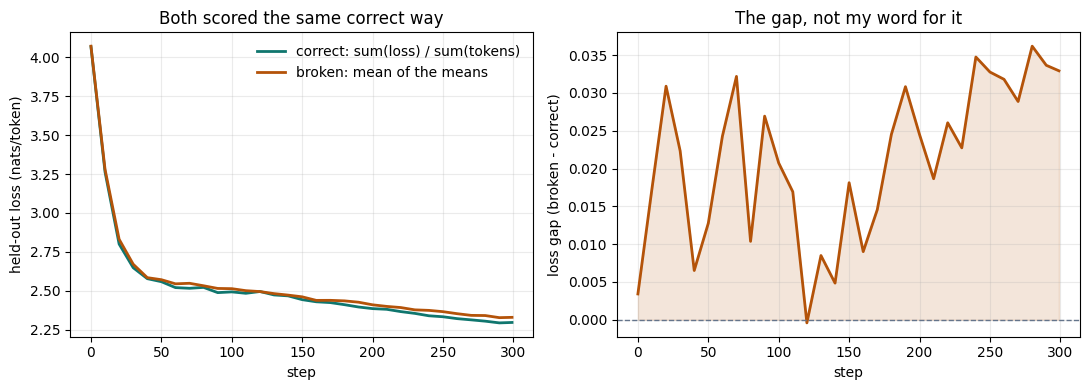

final gap: +0.0329 nats/token


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["correct"]["step"], hist["correct"]["val"],
           color="#0F766E", lw=2, label="correct: sum(loss) / sum(tokens)")
ax[0].plot(hist["mean_of_means"]["step"], hist["mean_of_means"]["val"],
           color="#B45309", lw=2, label="broken: mean of the means")
ax[0].set_xlabel("step"); ax[0].set_ylabel("held-out loss (nats/token)")
ax[0].set_title("Both scored the same correct way"); ax[0].legend(frameon=False)

gap = [b - c for b, c in zip(hist["mean_of_means"]["val"], hist["correct"]["val"])]
ax[1].plot(hist["correct"]["step"], gap, color="#B45309", lw=2)
ax[1].fill_between(hist["correct"]["step"], 0, gap, color="#B45309", alpha=0.15)
ax[1].axhline(0, color="#64748B", ls="--", lw=1)
ax[1].set_xlabel("step"); ax[1].set_ylabel("loss gap (broken - correct)")
ax[1].set_title("The gap, not my word for it")
for a in ax: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()
print(f"final gap: {gap[-1]:+.4f} nats/token")

---
## Q4. Log the grad norm every step; find a step where it moved first

The loss at step $t$ is a property of the weights *before* step $t$'s update. The grad norm
at step $t$ sizes the update that produces the weights measured at step $t+1$:

$$\text{grad norm at } t \;\longrightarrow\; \text{update at } t \;\longrightarrow\; \text{loss at } t+1$$

A derivative moves before a level, almost by construction.

Two honesty constraints. **(1)** Every baseline is *causal* - an EMA of strictly past
values. A centred window would let the future leak into "was this a surprise", which would
manufacture the very lead we are testing for. **(2)** The per-step training loss uses a
different random batch each step, so its wobble is mostly batch difficulty, not model
change. A **fixed probe batch** is evaluated every step so that a change in it can only
come from the weights.

In [9]:
from src.train import TrainConfig, train
from src.gradnorm import find_lead_steps, rank_hits, describe_hit, lag_correlation

_, log = train(ds, TrainConfig(steps=400, log_every=100, device=str(DEV)),
               verbose=True, probe=True)
hits, zl, zg = find_lead_steps(log, loss_key="probe_loss")
print(f"\nlead-step candidates: {len(hits)}")
print()
print(describe_hit(rank_hits(hits)[0], log, loss_key="probe_loss"))

step    0 | loss 4.2046 | gnorm  4.6081 | lr 1.00e-04 |   93.7 ms
step  100 | loss 2.5541 | gnorm  0.6226 | lr 2.77e-03 |   15.6 ms
step  200 | loss 2.3580 | gnorm  0.5386 | lr 1.82e-03 |   15.1 ms
step  300 | loss 2.2430 | gnorm  0.7312 | lr 7.58e-04 |   16.9 ms
step  399 | loss 2.1544 | gnorm  1.0362 | lr 3.00e-04 |   15.6 ms

lead-step candidates: 3

step 358: the gradient moved, the loss did not.

  step   grad norm      d(gn)    z(gn)       loss    d(loss)   z(loss)
--------------------------------------------------------------------------
   355      1.2321    +0.4251    +1.19     2.2687    +0.0000     +0.60
   356      0.9055    -0.3265    -0.51     2.2664    -0.0023     -0.04
   357      0.7677    -0.1378    -1.14     2.2653    -0.0011     -0.35
   358      1.4292    +0.6615    +2.27     2.2638    -0.0016     -0.79  <-- grad norm jumps here
   359      1.5253    +0.0961    +1.95     2.2592    -0.0046     -2.14
   360      0.8291    -0.6962    -0.96     2.2523    -0.0069     -3.

A single step could be luck. The lagged cross-correlation is the check on that - it is a
statement about the whole run rather than one cherry-picked step. Read the result
honestly, whichever way it comes out.

In [10]:
for r in lag_correlation(log, loss_key="probe_loss"):
    print(f"  lag {r['lag']:+d}: {r['corr']:+.4f}  " + "#" * int(max(0, r['corr']) * 60))

  lag -6: -0.0625  
  lag -5: -0.0383  
  lag -4: +0.0149  
  lag -3: +0.0340  ##
  lag -2: +0.0900  #####
  lag -1: +0.1119  ######
  lag +0: +0.0481  ##
  lag +1: +0.0808  ####
  lag +2: -0.0214  
  lag +3: -0.0721  
  lag +4: -0.0813  
  lag +5: -0.0264  
  lag +6: +0.1306  #######


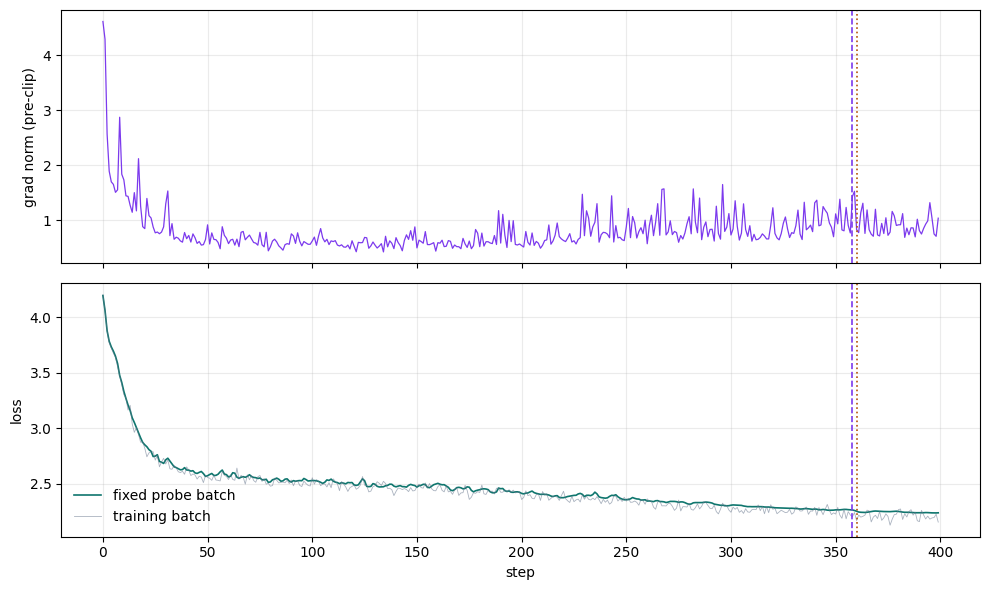

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
st = log.col("step")
ax[0].plot(st, log.col("grad_norm"), color="#7C3AED", lw=0.9)
ax[0].set_ylabel("grad norm (pre-clip)")
ax[1].plot(st, log.col("probe_loss"), color="#0F766E", lw=1.2, label="fixed probe batch")
ax[1].plot(st, log.col("loss"), color="#64748B", lw=0.6, alpha=0.55, label="training batch")
ax[1].set_ylabel("loss"); ax[1].set_xlabel("step"); ax[1].legend(frameon=False)
b = rank_hits(hits)[0]
for a in ax:
    a.axvline(b["step"], color="#7C3AED", ls="--", lw=1.2)
    a.axvline(b["reacts_at"], color="#B45309", ls=":", lw=1.2)
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### The test designed to settle it either way

A single step could be luck, and the lagged correlation above is buried in noise. So ask the
question as a **symmetry test** instead, which is much harder to fool — run the *identical*
detector in both directions with *identical* thresholds:

- *forward*: grad norm surprises at $t$, loss is quiet at $t$, loss moves by $t+3$
- *reverse*: loss surprises at $t$, grad norm is quiet at $t$, grad norm moves by $t+3$

Any imbalance is then a property of the training dynamics rather than of the test. And a
ratio with no p-value attached is how you end up believing noise, so it reports an exact
two-sided binomial test against a 50/50 null.

In [12]:
from src.gradnorm import lead_symmetry_test
sym = lead_symmetry_test(ds, steps=250, device=DEV)

  seed  1337: grad-norm-leads   2   loss-leads   2
  seed     7: grad-norm-leads   5   loss-leads   1
  seed    21: grad-norm-leads   5   loss-leads   3
  seed    99: grad-norm-leads   3   loss-leads   3
  seed  2024: grad-norm-leads   3   loss-leads   1
  --------------------------------------------
       total: grad-norm-leads  18   loss-leads  10
  verdict: grad norm leads 1.80x more often (64% of 28 events)
  exact two-sided binomial test vs 50/50: p = 0.185  ->  NOT significant at the 5% level
  so: the lean is in the predicted direction, but 28 events is too
      few to call it. Reported as suggestive, not established.


**Corroboration at large amplitude.** Same mechanism, turned up until it is loud: a
learning rate past the stable range, with clipping off.

In [13]:
from src.gradnorm import instability_run
ilog = instability_run(ds, steps=150, device=DEV)
ihits, _, _ = find_lead_steps(ilog, loss_key="probe_loss", warmup=8)
if ihits:
    print(describe_hit(rank_hits(ihits)[0], ilog, loss_key="probe_loss"))

### The honest conclusion

- The **anecdote is real** — the trace above shows it.
- The **mechanism is real**: the loss at step $t$ cannot reflect the update made at step $t$,
  so a lead of at least one step is forced by the ordering of operations, not by any
  empirical claim.
- Whether the lead is **systematic** is decided by the p-value printed above, not by the
  ratio. Read it before believing the ratio.

Why is it so hard to see in a healthy run? **When training is going well, nothing surprising
happens.** The grad norm is a leading indicator of *trouble* — spikes, divergence, a bad
batch, a learning rate past the stable range — and a stable run has little of that to lead.

---
## Q5. MFU, honestly

$$\text{MFU} = \frac{\text{model FLOPs required per second}}{\text{peak FLOPs the device can do}}$$

"Model FLOPs" is the arithmetic the *maths* demands, not the arithmetic the hardware
happened to run. Recomputation, padding and masked-away attention cost real time and earn
no credit - that is the point.

Per token, forward: weight matmuls contribute $2 N_{mm}$ where
$N_{mm} = L\cdot 12C^2 + VC$, and the parameter-free attention matmuls contribute
$4LTC$. Backward costs $2\times$ forward, so

$$\text{FLOPs/token} = 6 N_{mm} + 12\,L\,T\,C$$

The denominator is the arguable half, so every one that could be defended is reported:
the datasheet peak, the best throughput a large fp32 GEMM actually reaches on this device,
and - on a GPU - the tensor-core ceiling, which is the denominator the published "40% MFU"
figures are quoted against. They differ by more than an order of magnitude, so an MFU
number without its denominator attached means nothing.

In [14]:
from src.model import GPTConfig
from src.mfu import compute_mfu

cfg = GPTConfig(vocab_size=ds.vocab_size, block_size=128, n_layer=4, n_head=4, n_embd=128)
mfu = compute_mfu(ds, cfg, batch_size=16, seq_len=128, reps=20, device=DEV)

device : Tesla T4  [cuda]
         40 SMs, compute capability 7.5, 15.6 GB, bf16 yes
         Turing: fp16 tensor cores, no bf16 and no TF32

datasheet fp32 peak       :     8.10 TFLOP/s
tensor-core peak          :    65.00 TFLOP/s

measured GEMM ceilings on this device (what it really reaches):
  fp32      6.09 TFLOP/s  =  75.2% of datasheet fp32
  tf32      4.08 TFLOP/s
  bf16      2.38 TFLOP/s
  -> the model trains in fp32, so its ceiling is 6.09 TFLOP/s

model FLOPs accounting (B=16, T=128):
  matmul parameters        : 794,752
  fwd weight FLOPs/token   : 1,589,504
  fwd attention FLOPs/token: 262,144  (14.2% of forward)
  total FLOPs/token (f+b)  : 5,554,944
  FLOPs per step           : 11.3765 GFLOP

measured step time        : 12.38 ms  (165,446 tokens/s)
achieved                  :   919.04 GFLOP/s

  MFU vs datasheet fp32 peak   : 11.35%
  MFU vs measured fp32 ceiling : 15.08%   <- the honest one

where the step time actually goes:
  data         0.64 ms    5.1%
  forward    

### Where does the distance to 40% go?

Four candidate explanations. Measure all four rather than picking a favourite.

**(a) Are the matmul shapes bad?** A matmul with a small `K` or `N` cannot saturate a
vector unit however good the kernel is.

In [15]:
from src.mfu import matmul_shape_census
peak = mfu["peak"]["gflops"]
census = matmul_shape_census(cfg, 16, 128, peak, device=DEV)
tot = sum(r["flops"] for r in census)
print(f"{'matmul':<30} {'GFLOP/s':>9} {'% of peak':>10} {'FLOP share':>11}")
print("-" * 64)
for r in census:
    print(f"{r['name']:<30} {r['gflops']:>9.1f} {r['frac_of_peak']:>9.1%} {r['flops']/tot:>10.1%}")
ceiling = tot / sum(r['flops']/(r['gflops']*1e9) for r in census) / 1e9
print(f"\nFLOP-weighted matmul throughput: {ceiling:.1f} GFLOP/s = {ceiling/peak:.1%} of peak")

matmul                           GFLOP/s  % of peak  FLOP share
----------------------------------------------------------------
c_attn   (B*T,C)x(C,3C)           1883.1     30.9%      21.2%
attn QK^T per head                1281.1     21.0%       7.1%
attn AV   per head                1086.2     17.8%       7.1%
attn c_proj (B*T,C)x(C,C)         1611.3     26.4%       7.1%
mlp c_fc  (B*T,C)x(C,4C)          2113.7     34.7%      28.3%
mlp c_proj (B*T,4C)x(4C,C)        2129.1     34.9%      28.3%
lm_head  (B*T,C)x(C,V)             682.0     11.2%       0.9%

FLOP-weighted matmul throughput: 1794.5 GFLOP/s = 29.4% of peak


**(b) How much of the step is matmul at all?** Only `mm`/`addmm`/`bmm` earn model FLOPs.
Softmax, GELU, LayerNorm, the causal `masked_fill`, the transpose copies and the AdamW
update all cost wall clock and earn nothing.

In [16]:
from src.mfu import op_attribution
attr = op_attribution(ds, cfg, device=DEV)
print(f"matmul ops      : {attr['matmul_frac']:.1%} of step time")
print(f"everything else : {attr['other_frac']:.1%} of step time\n")
for k, t, c in attr["rows"][:12]:
    tag = "  <- matmul" if k in {"aten::mm","aten::addmm","aten::bmm"} else ""
    print(f"  {k:<34} {t/attr['total_us']:>6.1%}  {c:>6} calls{tag}")

/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


matmul ops      : 22.5% of step time
everything else : 77.5% of step time

  aten::mm                            10.7%     175 calls  <- matmul
  Optimizer.step#AdamW.step            6.4%       5 calls
  aten::addmm                          6.2%      80 calls  <- matmul
  volta_sgemm_128x64_nn                6.1%     105 calls
  aten::bmm                            5.5%     120 calls  <- matmul
  volta_sgemm_128x64_tn                5.5%      80 calls
  aten::copy_                          4.0%     185 calls
  volta_sgemm_64x64_nt                 3.4%      60 calls
  aten::mul                            3.2%      60 calls
  volta_sgemm_64x64_tn                 2.8%      40 calls
  aten::sum                            2.5%      90 calls
  void at::native::reduce_kernel<128, 4, at::native::ReduceOp<float, at::native::func_wrapper_t<float, at::native::sum_functor<float, float, float>::operator()(at::TensorIterator&)::{lambda(float, float)#1}>, unsigned int, float, 4, 4> >(at::native::Redu

**(c) Is it the machine, or the model size?** These two hypotheses make opposite
predictions. If low MFU were something fundamental about this CPU, growing the model would
not help. If it is fixed per-step overhead that does not scale with $C^2$, growing the
model fixes it. That is a decidable question.

In [17]:
from src.mfu import size_sweep
sizes = size_sweep(ds, device=DEV)

n_embd layers   B    T      params  ms/step  GFLOP/s     MFU
---------------------------------------------------------------
   128      4  32  256     834,432     40.2   1292.6   30.7%
   256      4  32  256   3,241,728     83.3   2176.2   56.4%
   512      4  32  256  12,774,912    254.5   2639.1   77.7%
   768      4  32  256  28,599,552    534.6   2752.1   84.3%
  1024      4  32  256  50,715,648    880.5   2930.6   88.0%


**(d) Is it the dtype?** On a GPU this is the first-order term and it is pure
bookkeeping: the model trains in fp32, so it runs on the CUDA cores and cannot touch
the tensor cores at all. The 40% figures are quoted against the *tensor-core* peak.
Same numerator, a denominator several times larger - so the two numbers are not
comparable, and saying "my MFU is X%" without naming the denominator is meaningless.

In [18]:
# Same measured run. Every denominator that could honestly be used.
peaks = mfu["peak"]["by_dtype"]
ach = mfu["achieved_flops"] / 1e9
print(f"achieved by this step              : {ach:8.1f} GFLOP/s\n")
for tag, gf in peaks.items():
    print(f"  MFU vs measured {tag:<4} ceiling    : {ach/gf:7.2%}   (ceiling {gf/1e3:6.2f} TFLOP/s)")
lowp_tag = "bf16" if "bf16" in peaks else ("fp16" if "fp16" in peaks else None)
if lowp_tag:
    r = peaks[lowp_tag] / peaks["fp32"]
    print(f"\nfp32 -> {lowp_tag} is a {r:.1f}x change in the ceiling that this run never uses.")
    print(f"Reaching 40% of the {lowp_tag} ceiling would need "
          f"{0.40 * peaks[lowp_tag] / ach:.0f}x this step's throughput.")

achieved by this step              :    919.0 GFLOP/s

  MFU vs measured fp32 ceiling    :  15.08%   (ceiling   6.09 TFLOP/s)
  MFU vs measured tf32 ceiling    :  22.50%   (ceiling   4.08 TFLOP/s)
  MFU vs measured bf16 ceiling    :  38.67%   (ceiling   2.38 TFLOP/s)

fp32 -> bf16 is a 0.4x change in the ceiling that this run never uses.
Reaching 40% of the bf16 ceiling would need 1x this step's throughput.


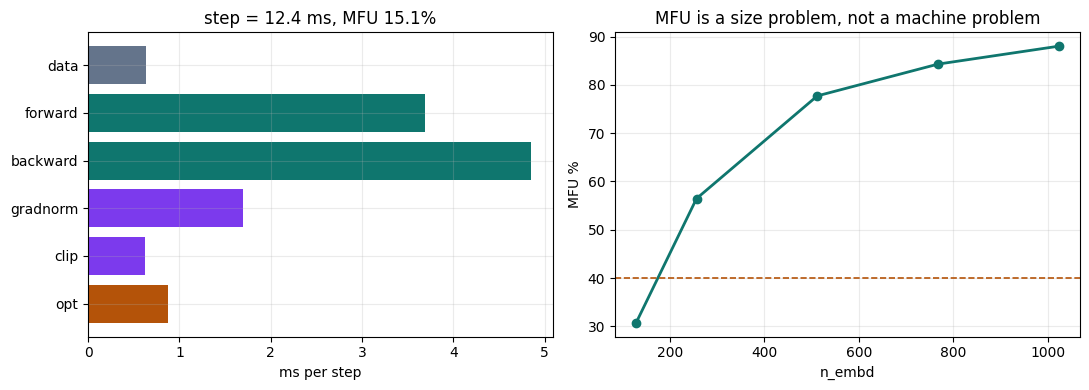

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labels = ["data","forward","backward","gradnorm","clip","opt"]
ax[0].barh(labels, [mfu["phases"][k]*1e3 for k in labels],
           color=["#64748B","#0F766E","#0F766E","#7C3AED","#7C3AED","#B45309"])
ax[0].invert_yaxis(); ax[0].set_xlabel("ms per step")
ax[0].set_title(f"step = {mfu['dt']*1e3:.1f} ms, MFU {mfu['mfu_measured_ceiling']:.1%}")
ax[1].plot([r["n_embd"] for r in sizes], [r["mfu"]*100 for r in sizes],
           "o-", color="#0F766E", lw=2)
ax[1].axhline(40, color="#B45309", ls="--", lw=1.2)
ax[1].set_xlabel("n_embd"); ax[1].set_ylabel("MFU %")
ax[1].set_title("MFU is a size problem, not a machine problem")
for a in ax: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

---
## Q6. 0.1 in fp32, bf16 and fp8 E4M3

0.1 is not representable in binary, for the same reason 1/3 is not representable in
decimal: $10 = 2\times 5$, and that factor of 5 is not a power of the base.

$$0.1 \times 2 = 0.2 \to 0,\quad 0.2\times 2 = 0.4 \to 0,\quad 0.4\times2=0.8\to0,\quad
0.8\times2=1.6\to1,\quad 0.6\times2=1.2\to1,\quad 0.2\ \text{again}\ \dots$$

$$0.1 = 0.0\overline{0011}_2 = 1.\overline{1001}_2 \times 2^{-4}$$

So in **all three** formats the sign is 0 and the unbiased exponent is $-4$. The only thing
that changes is how many bits of the repeating mantissa $0.6 = .\overline{1001}_2$ survive,
and which way the leftovers round.

Every derivation below is done in exact rational arithmetic (`fractions.Fraction`), never
in floating point - so the "by hand" answer cannot inherit an error from the thing it is
checking - and each is then verified against the real hardware bits.

In [20]:
from src.floats import report, precision_table, accumulation_demo
fl = report()
print("all hand-derived bit patterns match hardware:", all(r["bits_match"] for r in fl))

decimal 0.1 = exactly 1/10
in binary: 0.0(0011) repeating  =  1.1001100110011... x 2^-4
so in every format below: sign = 0, unbiased exponent = -4,
and the mantissa is as many bits of 0.6 = .1001 1001 1001... as will fit.

--- fp32  (32 bits: 1 sign + 8 exponent + 23 mantissa, bias 127) ---
  IEEE 754 binary32
  exponent field : -4 + 127 = 123 = 01111011
  mantissa field : 10011001100110011001101   (rounded UP; discarded tail = 0.8000 of an ulp)
  bit pattern    : 0 01111011 10011001100110011001101   = 0x3DCCCCCD
  hardware says  : 0x3DCCCCCD   -> MATCH
  value stored   : 13421773/134217728 = 0.10000000149011612
  relative error : 1.490e-08   (0.0000%)

--- bf16  (16 bits: 1 sign + 8 exponent + 7 mantissa, bias 127) ---
  fp32 with 16 mantissa bits chopped off
  exponent field : -4 + 127 = 123 = 01111011
  mantissa field : 1001101   (rounded UP; discarded tail = 0.8000 of an ulp)
  bit pattern    : 0 01111011 1001101   = 0x3DCD
  hardware says  : 0x3DCD   -> MATCH
  value stored   : 20

In [21]:
_ = precision_table()

format     bits  e  m  eps (2^-m) ~dec digits  min normal  max normal       range
----------------------------------------------------------------------------------
fp32         32  8 23   1.192e-07         7.9    1.18e-38    3.40e+38     76.5 dec
bf16         16  8  7   7.812e-03         3.1    1.18e-38    3.39e+38     76.5 dec
fp8 E4M3      8  4  3   1.250e-01         1.9    1.56e-02    4.48e+02      4.5 dec


### Which would I train in?

The one-off rounding error of a single 0.1 is not what decides this. What decides it is
that error **compounding**, which is exactly what gradient accumulation and optimizer
state do all day. Add 0.1 to itself 1000 times in each format:

In [22]:
_ = accumulation_demo()

adding 0.1 to itself 1000 times (exact answer: 100.0):
format               result   relative error
----------------------------------------------
fp32              99.999046          0.001%
bf16              32.000000         68.000%
fp8 E4M3           2.000000         98.000%


bf16 stalls at 32 and fp8 at 2, and neither is a rounding curiosity - it is **swamping**.
Once the accumulator grows large enough that the addend falls below *half an ulp* of it,
`acc + x` rounds straight back to `acc` and the sum stops moving forever.

The stall values are predicted exactly by the ulp arithmetic. For a format with $m$ mantissa
bits and an accumulator whose exponent is $e$, one ulp is $2^{e-m}$:

| | $e$ | ulp $=2^{e-m}$ | half-ulp | is $0.1$ above it? | `acc + 0.1` |
|---|---|---|---|---|---|
| bf16 at 16 | 4 | $2^{-3}=0.125$ | 0.0625 | yes | 16.125, still moving |
| **bf16 at 32** | 5 | $2^{-2}=0.25$ | **0.125** | **no** | **32.0, dead** |
| fp8 at 1.875 | 0 | $2^{-3}=0.125$ | 0.0625 | yes | 2.0, still moving |
| **fp8 at 2** | 1 | $2^{-2}=0.25$ | **0.125** | **no** | **2.0, dead** |

Each format dies at exactly the value where its ulp doubles past $0.2$.

**The answer: bf16 for the matmuls, fp32 for anything that accumulates.**

- **Not fp32 everywhere.** It is the safe choice and roughly half the speed. On any tensor-core
  machine you are leaving most of the throughput unused for precision the gradients do not need.
- **bf16 over fp16** - and this is the reason bf16 exists. It keeps all 8 exponent bits, so it
  has the *same dynamic range as fp32* (76.5 decades in the table above) and trades mantissa
  bits instead. Gradients underflow long before they lose meaningful precision, so range is the
  scarce resource. That is also why bf16 needs no loss scaling and fp16 does.
- **Not fp8 E4M3 for the whole loop.** 4.5 decades of range and ~1.9 decimal digits is enough
  for a forward matmul with per-tensor scaling, which is exactly how it is used in practice -
  but master weights, the optimizer moments and the accumulation all stay in fp32. The 1000-add
  experiment above is what happens if you forget that.

The rule underneath all of it: **exponent bits buy you range, mantissa bits buy you precision,
and training runs out of range before it runs out of precision.**

---
## Summary

Every number above came from this run, on the device named in the first cell.
The cell below collects the headline ones so they can be pasted straight into
`README.md` - the README's job is to report what a run measured, not what a run
measured once on some other machine.

Run `python run_all.py` for the same six answers as text and figures in `artifacts/`.

In [23]:
# --- headline numbers from THIS run, for the README ------------------------
import json

summary = {
    "device": str(DEV),
    "device_name": info["name"],
    "torch": torch.__version__,
    "q2_gradcheck_rel_err": gc1["rel_err"],
    "q2_matching_digits": gc1["matching_digits"],
    "q3_final_gap_nats_per_token":
        hist["mean_of_means"]["val"][-1] - hist["correct"]["val"][-1],
    "q3_grad_cosine": cmp1["cos"],
    "q3_grad_angle_deg": cmp1["angle_deg"],
    "q4_symmetry_forward": sym["forward"],
    "q4_symmetry_reverse": sym["reverse"],
    "q4_symmetry_p_value": sym["p_value"],
    "q5_step_ms": mfu["dt"] * 1e3,
    "q5_achieved_gflops": mfu["achieved_flops"] / 1e9,
    "q5_peak_by_dtype_gflops": mfu["peak"]["by_dtype"],
    "q5_mfu_vs_measured_fp32": mfu["mfu_measured_ceiling"],
    "q5_mfu_vs_datasheet_fp32": mfu["mfu_theoretical"],
    "q5_mfu_vs_lowp_ceiling": mfu["mfu_vs_lowp_ceiling"],
    "q5_phases_ms": {k: v * 1e3 for k, v in mfu["phases"].items()},
    "q5_matmul_frac_of_step": attr["matmul_frac"],
    "q5_size_sweep": [(r["n_embd"], r["mfu"]) for r in sizes],
}
print(json.dumps(summary, indent=2, default=float))

{
  "device": "cuda",
  "device_name": "Tesla T4",
  "torch": "2.11.0+cu128",
  "q2_gradcheck_rel_err": 9.215729697077134e-09,
  "q2_matching_digits": 8.035470271853741,
  "q3_final_gap_nats_per_token": 0.03292261362075788,
  "q3_grad_cosine": 0.9967350998696208,
  "q3_grad_angle_deg": 4.631174087524414,
  "q4_symmetry_forward": 18,
  "q4_symmetry_reverse": 10,
  "q4_symmetry_p_value": 0.1849333420395851,
  "q5_step_ms": 12.37864959999797,
  "q5_achieved_gflops": 919.044134830496,
  "q5_peak_by_dtype_gflops": {
    "fp32": 6094.930303188699,
    "tf32": 4084.045975812366,
    "bf16": 2376.5315287425174
  },
  "q5_mfu_vs_measured_fp32": 0.15078829274711764,
  "q5_mfu_vs_datasheet_fp32": 0.11346223886796246,
  "q5_mfu_vs_lowp_ceiling": 0.3867165756966773,
  "q5_phases_ms": {
    "data": 0.6372703994414942,
    "forward": 3.6881010771403737,
    "backward": 4.850680622028639,
    "gradnorm": 1.700057325770919,
    "clip": 0.6279964018344188,
    "opt": 0.8745437737821256,
    "total": 12.